## Pipeline

# Welcome to Pipelines!

The HuggingFace transformers library provides APIs at two different levels.

The High Level API for using open-source models for typical inference tasks is called "pipelines". It's incredibly easy to use.

We create a pipeline using something like:

`my_pipeline = pipeline("the_task_I_want_to_do")`

Followed by

`result = my_pipeline(my_input)`

## A sidenote:

### 1. Training  

**Training** is when you provide a model with data for it to adapt to get better at a task in the future. It does this by updating its internal settings - the parameters or weights of the model. If you're Training a model that's already had some training, the activity is called "fine-tuning".

### 2. Inference

**Inference** is when you are working with a model that has _already been trained_. You are using that model to produce new outputs on new inputs, taking advantage of everything it learned while it was being trained. Inference is also sometimes referred to as "Execution" or "Running a model".

All of our use of APIs for GPT, Claude and Gemini in the last weeks are examples of **inference**. The "P" in GPT stands for "Pre-trained", meaning that it has already been trained with data (lots of it!) In week 6 we will try fine-tuning GPT ourselves.
  
The pipelines API in HuggingFace is only for use for **inference** - running a model that has already been trained. In week 7 we will be training our own model, and we will need to use the more advanced HuggingFace APIs that we look at in the up-coming lecture.


In [1]:
%pip install -q --upgrade datasets==3.6.0 transformers==4.57.6

Note: you may need to restart the kernel to use updated packages.


display # Used to render the final image directly in your browser

torch # Deep Learning framework (PyTorch) used to handle the heavy
mathematical lifting and GPU communication.

"stabilityai/sdxl-turbo": This points to the specific model weights hosted on Hugging Face. SDXL Turbo is unique because it uses a technique called Adversarial Diffusion Distillation (ADD) to generate images in 1–4 steps instead of the usual 30–50.

torch.float16 / variant="fp16": This loads the model in "Half Precision." It makes the model run significantly faster and use less VRAM without a noticeable drop in image quality.

.to("cuda"): This moves the model from your system RAM to your NVIDIA GPU's memory. This code will fail if you don't have a GPU available.

----------------------------------------------------------------------------

pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]

This is where the "magic" happens. Three specific parameters are key here:

prompt: Your text description.

num_inference_steps=4: Because this is the "Turbo" version, it only needs 4 passes to turn random noise into a clear image.

guidance_scale=0.0: Usually, this tells the model how strictly to follow your prompt. However, SDXL Turbo was trained to ignore this parameter (it’s baked into the model), so setting it to 0.0 is standard for this specific version.

The result is an object stored in image (usually a PIL Image format), which is then shown via display(image).

In a standard setup, generating an image might take 10–20 seconds. With this specific SDXL Turbo configuration, you can often generate a high-resolution image in well under a second on a modern GPU.

In [2]:
%pip install -q diffusers transformers accelerate

Note: you may need to restart the kernel to use updated packages.


In [3]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

/Users/pradeepkumar/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For M2's GPU power: need to use Apple's MPS (Metal Performance Shaders) backend instead of CUDA(used for nvedia - google colab).

100%|██████████| 4/4 [00:08<00:00,  2.14s/it]
/Users/pradeepkumar/miniconda3/lib/python3.13/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


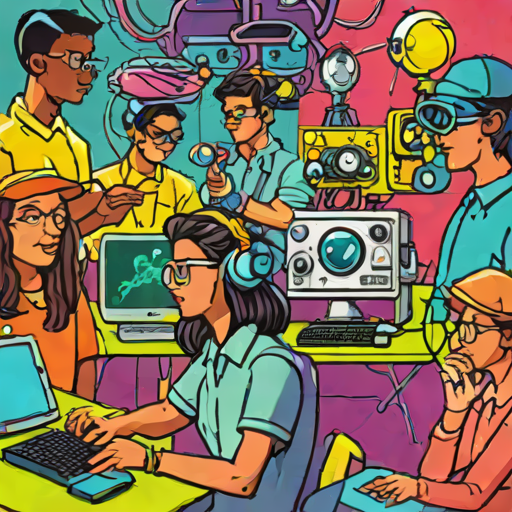

In [5]:
#Loading the Model
pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("mps")
prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

In [8]:
%pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Audio Generation

from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='mps')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi to an artificial intelligence engineer, on the way to mastery!", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

/Users/pradeepkumar/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps
Generating validation split: 7931 examples [00:01, 4941.39 examples/s]


# All the available pipelines

Here are all the pipelines available from Transformers and Diffusers.

With thanks to student Lucky P for suggesting I include this!

There's a list pipelines under the Tasks on this page (you have to scroll down a bit, then expand the parameters to see the Tasks):

https://huggingface.co/docs/transformers/main_classes/pipelines

There's also this list of Tasks for Diffusion models instead of Transformers, following the image generation example where I use DiffusionPipeline above.

https://huggingface.co/docs/diffusers/en/api/pipelines/overview

If you come up with some cool examples of other pipelines, please share them with me! It's wonderful how HuggingFace makes this advanced AI functionality available for inference with such a simple API.